Upload an image with at least one human face (jpg, png):


Saving human.jpg to human (1).jpg


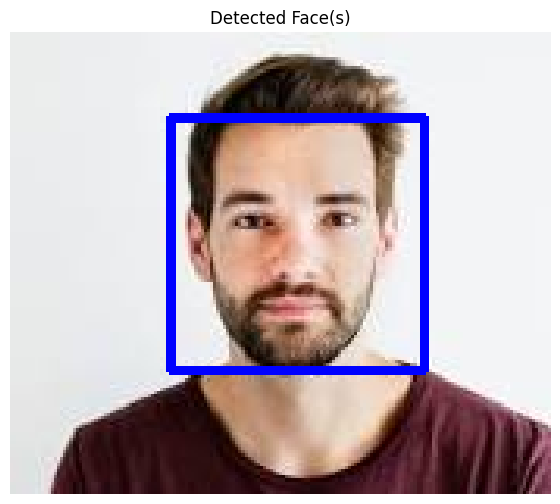

In [17]:
# Install OpenCV (headless version)
!pip install opencv-python-headless --quiet
import cv2
import matplotlib.pyplot as plt
from google.colab import files
# Step 1: Upload a face image
print("Upload an image with at least one human face (jpg, png):")
uploaded = files.upload()
image_path = list(uploaded.keys())[0]
# Step 2: Load Haar cascade for face detection
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades +
'haarcascade_frontalface_default.xml')
# Step 3: Read and convert the image to grayscale
img = cv2.imread(image_path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# Step 4: Detect faces
faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)
# Step 5: Draw rectangles around detected faces
for (x, y, w, h) in faces:
  cv2.rectangle(img, (x, y), (x + w, y + h), (255, 0, 0), 2)
# Step 6: Display the result using matplotlib
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(8, 6))
plt.imshow(img_rgb)
plt.title("Detected Face(s)")
plt.axis('off')
plt.show()

Upload a video file (e.g., .mp4, .avi):


Saving Free Video Templates Woman Turning Face Toward Camera Smiling  FULL HD, 1080P, 4K VIDEO - QTIT - Digital Marketing Agency (1080p, h264).mp4 to Free Video Templates Woman Turning Face Toward Camera Smiling  FULL HD, 1080P, 4K VIDEO - QTIT - Digital Marketing Agency (1080p, h264) (3).mp4


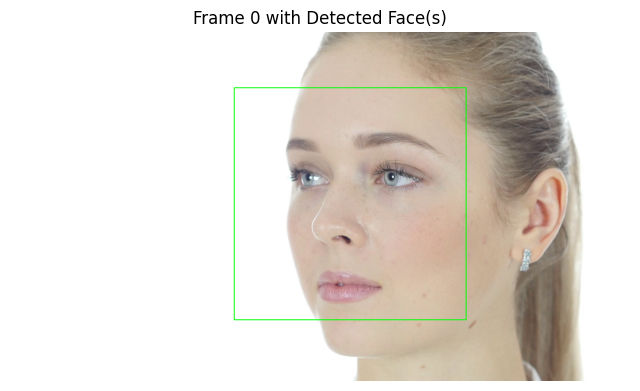

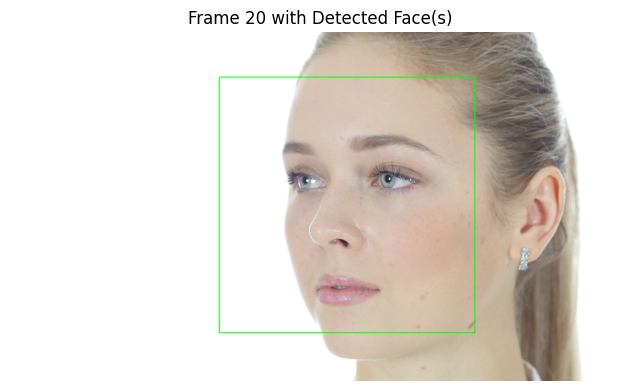

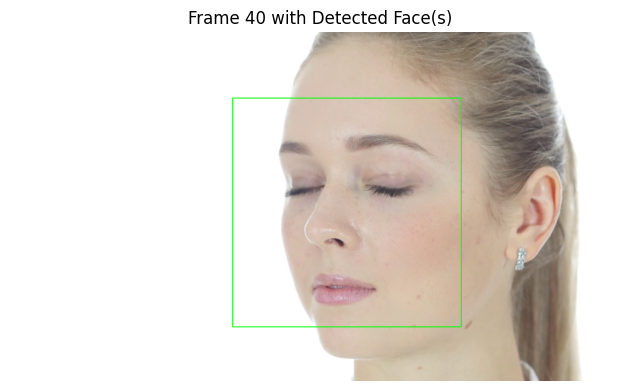

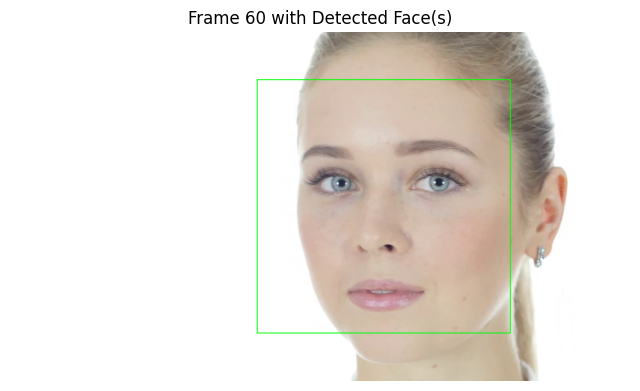

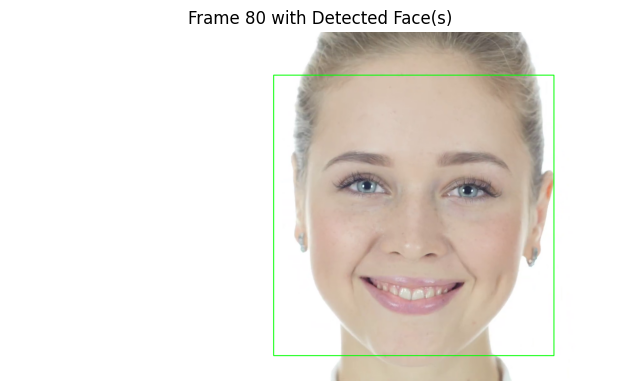

In [18]:
# Install OpenCV
!pip install opencv-python-headless --quiet
import cv2
import matplotlib.pyplot as plt
from google.colab import files
import os

# Step 1: Upload a short video with a human face
print("Upload a video file (e.g., .mp4, .avi):")
uploaded = files.upload()
video_path = list(uploaded.keys())[0]

# Step 2: Load the Haar Cascade for face detection
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades +
'haarcascade_frontalface_default.xml')

# Step 3: Read video file
cap = cv2.VideoCapture(video_path)
frame_count = 0

while True:
  ret, frame = cap.read()
  if not ret or frame_count >= 100: # limit to 100 frames to avoid long runtime
    break

  gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
  faces = face_cascade.detectMultiScale(gray, 1.1, 4)

  for (x, y, w, h) in faces:
    cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)

  # Display every 20th frame inside the loop
  if frame_count % 20 == 0:
    # Convert BGR to RGB for matplotlib for the current frame
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(8, 5))
    plt.imshow(rgb)
    plt.title(f"Frame {frame_count} with Detected Face(s)")
    plt.axis('off')
    plt.show()

  frame_count += 1 # Increment frame_count for every frame processed

# Release the video capture object after the loop
cap.release()

In [ ]:
import os
import cv2
import numpy as np
from google.colab import files # Added for file upload
import zipfile # Added for zip extraction
from matplotlib import pyplot as plt

# -------------------------------
# 1. Load Dataset
# -------------------------------
def load_dataset(dataset_path):
    images = []
    labels = []
    label_dict = {}
    current_label = 0

    # Ensure the dataset_path exists before trying to list its contents
    if not os.path.exists(dataset_path):
        print(f"Error: Dataset path '{dataset_path}' does not exist. Please verify its presence or correct extraction.")
        return images, labels, label_dict

    for person_name in os.listdir(dataset_path):
        person_path = os.path.join(dataset_path, person_name)

        if os.path.isdir(person_path):
            label_dict[current_label] = person_name

            for img_name in os.listdir(person_path):
                img_path = os.path.join(person_path, img_name)

                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

                if img is not None and img.shape[0] > 0 and img.shape[1] > 0:
                    img = cv2.resize(img, (200, 200))  # Resize for consistency
                    images.append(img)
                    labels.append(current_label)
                else:
                    print(f"Failed to load image: {img_path}")

            current_label += 1

    return images, labels, label_dict


# -------------------------------
# 2. Dataset Path (UPDATED)
# -------------------------------
dataset_path = 'face_recognition_dataset/Faces' # Relative path, will resolve to /content/face_recognition_dataset/Faces

# --- Handle missing dataset directory by prompting for upload and extraction ---
if not os.path.exists(dataset_path):
  print(f"Dataset directory not found at '{dataset_path}'.")
  print("Please upload your 'face_recognition_dataset.zip' file.")
  uploaded = files.upload()

  if uploaded:
    for fn in uploaded.keys():
      if fn.endswith('.zip'):
        print(f"Extracting '{fn}'...")
        with zipfile.ZipFile(fn, 'r') as zip_ref:
          # Extract to /content/, assuming the zip contains 'face_recognition_dataset/Faces/...' at its root
          zip_ref.extractall('/content/')
        print(f"Successfully extracted '{fn}'.")
        os.remove(fn) # Clean up the uploaded zip file

        # Verify if the target path now exists after extraction
        if not os.path.exists(dataset_path):
          print(f"Warning: After extraction, '{dataset_path}' still not found. Please ensure your zip file contains the correct directory structure (e.g., a folder named 'face_recognition_dataset' at the root, which then contains 'Faces').")
      else:
        print(f"Skipping non-zip file: '{fn}'. Please upload a .zip file.")
  else:
    print("No file uploaded. Cannot proceed without the dataset.")

# Proceed only if the dataset path now exists after potential extraction
if os.path.exists(dataset_path):
  images, labels, label_dict = load_dataset(dataset_path)

  if images: # Only proceed if images were successfully loaded
    # -------------------------------
    # 3. Train Model
    # -------------------------------
    recognizer = cv2.face.LBPHFaceRecognizer_create()
    recognizer.train(images, np.array(labels))

    # Save model
    recognizer.save('face_recognizer.yml')
    print("Face recognizer model saved as 'face_recognizer.yml'.")

    # Save label map
    with open("label_map.txt", "w") as f:
        for label, name in label_dict.items():
            f.write(f"{label}:{name}\n")
    print("Label map saved as 'label_map.txt'.")


    # -------------------------------
    # 4. Load Model & Label Map
    # -------------------------------
    recognizer = cv2.face.LBPHFaceRecognizer_create()
    recognizer.read("face_recognizer.yml")

    face_cascade = cv2.CascadeClassifier(
        cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
    )

    label_map = {}
    with open("label_map.txt", "r") as f:
        for line in f:
            label, name = line.strip().split(":")
            label_map[int(label)] = name


    # -------------------------------
    # 5. Test Image (UPDATED PATH)
    # -------------------------------
    # Updated path to match the extracted dataset structure if the zip file contains 'face_recognition_dataset' at root.
    # Assuming the structure is: /content/face_recognition_dataset/Original Images/Original Images/Akshay Kumar/Akshay Kumar_0.jpg
    test_image_path = "face_recognition_dataset/Original Images/Original Images/Akshay Kumar/Akshay Kumar_0.jpg"

    if os.path.exists(test_image_path):
      img = cv2.imread(test_image_path)

      if img is None:
          print(f"Error: Test image not found at '{test_image_path}' or could not be loaded!")
      else:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # -------------------------------
        # 6. Detect Faces
        # -------------------------------
        faces = face_cascade.detectMultiScale(gray, 1.3, 5)

        for (x, y, w, h) in faces:
            roi_gray = gray[y:y+h, x:x+w]
            roi_gray = cv2.resize(roi_gray, (200, 200))  # Important!

            label, confidence = recognizer.predict(roi_gray)

            # Confidence check (lower = better)
            if confidence < 70:
                name = label_map.get(label, "Unknown")
            else:
                name = "Unknown"

            # Draw rectangle & label
            cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2)
            cv2.putText(img, f"{name} ({int(confidence)})",
                        (x, y-10),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.8,
                        (0, 255, 0),
                        2)

        # -------------------------------
        # 7. Show Result
        # -------------------------------
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title("Face Recognition Result")
        plt.axis('off')
        plt.show()
    else:
      print(f"Error: Test image path '{test_image_path}' does not exist after dataset loading.")
  else:
    print("No images were loaded from the dataset. Face recognition training and testing skipped.")
else:
  print("Dataset directory still not found. Please re-run the cell and upload the correct 'face_recognition_dataset.zip' file.")

Dataset directory not found at 'face_recognition_dataset/Faces'.
Please upload your 'face_recognition_dataset.zip' file.


Saving akshyy.jpg to akshyy.jpg
Skipping non-zip file: 'akshyy.jpg'. Please upload a .zip file.
Dataset directory still not found. Please re-run the cell and upload the correct 'face_recognition_dataset.zip' file.
